### 로봇의 보급 임무

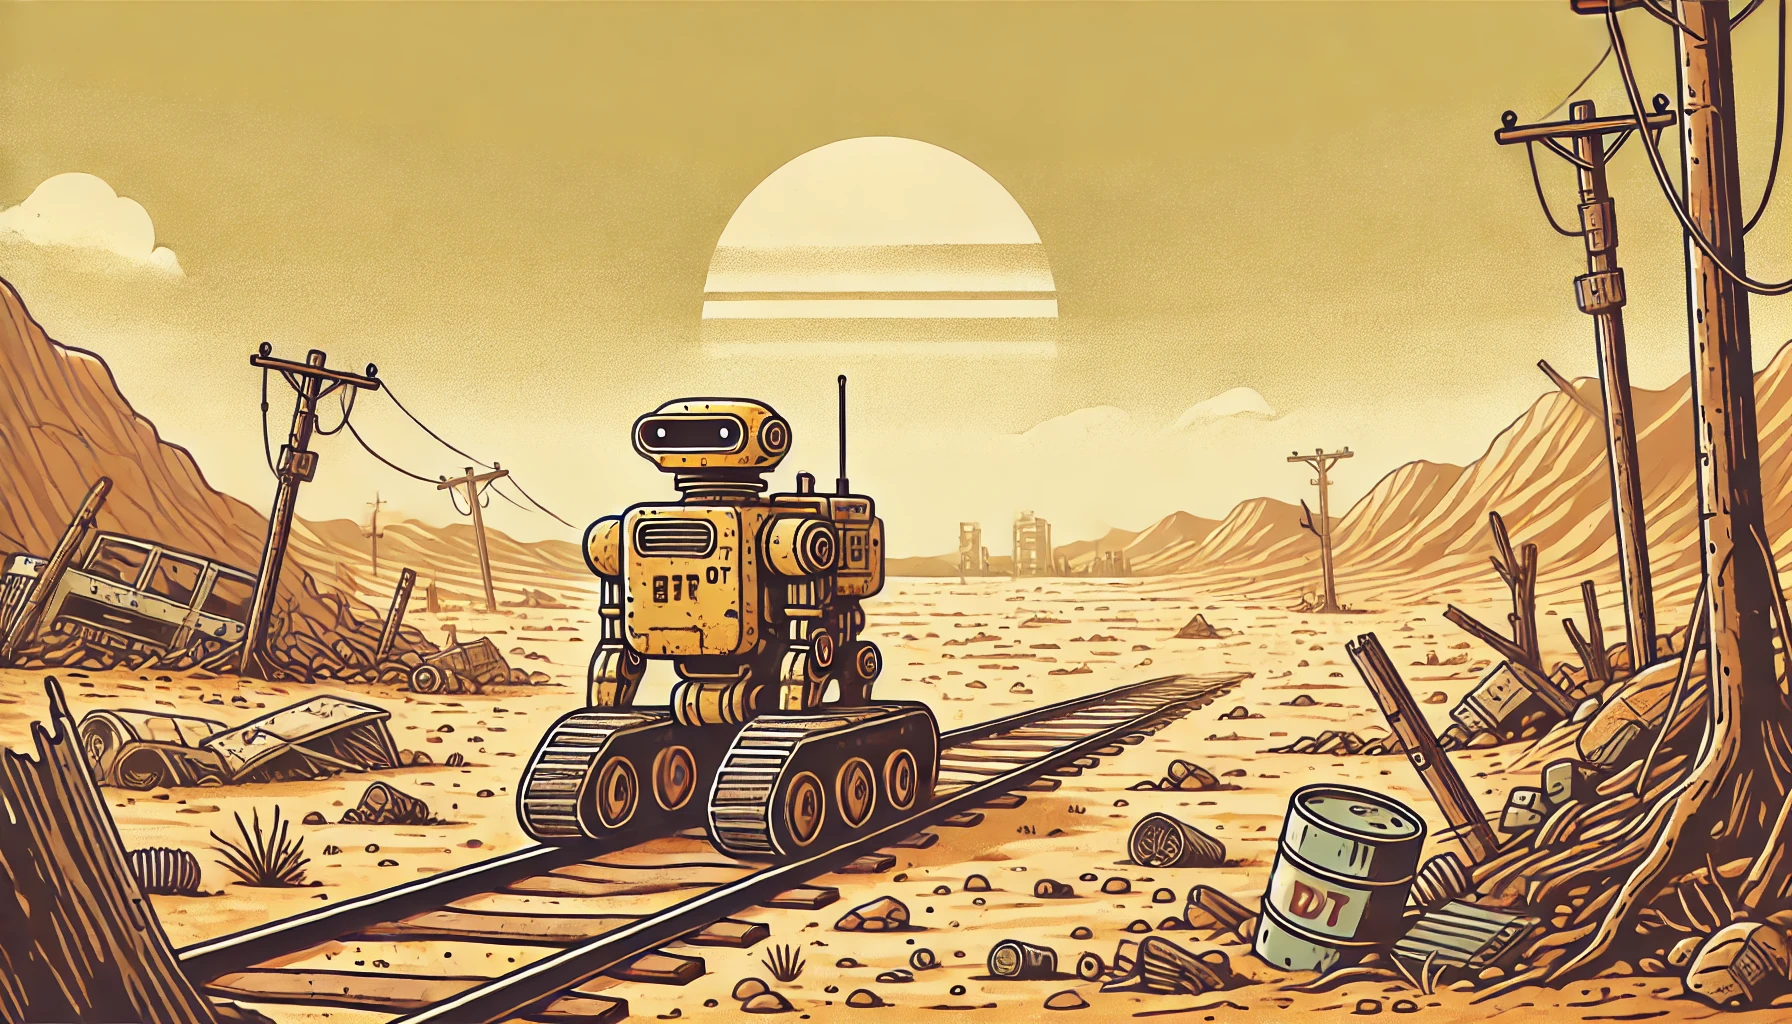

In [1]:
from IPython.display import Image
Image(filename="./images/Project 4.png")

### 문제

세계는 대규모 핵전쟁 이후 완전히 변해버렸습니다. 도시는 폐허가 되었고, 거리에는 방사능에 가득 노출된 잔해들만이 남게 되었습니다. 인류는 지하로 숨어들어가게 되었지만, 방사능에 강한 로봇들은 여전히 밖에서 다양한 임무를 수행할 수 있습니다.

AI 로봇 ‘AlgoX’는 황무지를 탐사하던 중 새로운 미션을 받게 되었습니다. 그건 바로 현재 위치에서 중간 보급 지점에 도착해 사람들의 보급품을 받은 후, 최종 목적지인 생존자 기지로 전달하는 임무였는데요. 다행히도 AlgoX는 인근 지도를 데이터로 저장하고 있습니다.

지도는 2차원 리스트를 통해 각 좌표에 관한 정보를 알려주는 방식으로 제공됩니다. “A”는 현재 AlgoX의 위치, “S“는 보급품의 위치, “B”는 생존자 기지를 의미하며, AlgoX가 지나갈 수 있는 칸은 “O”, 장애물로 인해 지나 갈 수 없는 칸은 “X”로 나타납니다. 이제 남은 건 AlgoX가 보급 지점에 방문한 뒤 생존자 기지로 돌아가는 최단 경로를 구하는 것입니다. 여러분이 로봇을 도와 AlgoX의 경로를 지도로 출력해 주세요.

### 조건

- **map_data**에는 각 좌표의 상태를 나타내는 지도 정보가 2차원 리스트로 저장되어 있습니다.
- **path_map**은 지도의 복사본으로, 여기에 AlgoX가 지나가야 하는 칸을 “*”로 표기합니다.
- **find_points()** 함수는 AlgoX의 초기 위치, 보급 지점, 생존자 기지 좌표를 찾아 start, supply, base 변수에 저장합니다.
- **bfs()** 함수는 입력된 출발지 좌표에서 목적지 좌표까지의 최단 거리를 구하고, 동선을 수집합니다.
    - **distances**에는 출발지로부터 각 좌표까지의 최단 거리를 저장합니다.
    - **previous**에는 해당 좌표를 최단 거리로 방문하기 이전에 머물러 있던 칸의 좌표를 저장합니다.
        - 예를 들어, (1, 2)에서 (1, 3)으로 이동했다면 previous[(1, 3)] = (1, 2)입니다.
        - 방문 가능한 인접 노드를 찾았을 때 인접 노드의 previous 값을 현재 노드로 설정하면 됩니다.
    - 너비 우선 탐색은 초기 위치 → 보급 지점, 그리고 보급 지점 → 생존자 기지로 총 2번 수행됩니다.
- **mark_path()** 함수는 지도의 복사본에 로봇의 경로를 표시하는 함수입니다.
    - previous를 이용해 목적지 좌표에서부터 거꾸로 이전 좌표를 확인해 오면, 출발지로부터 오는 경로를 알 수 있습니다.
    - 현재 좌표를 이전 좌표로 갱신하는 과정을, 현재 좌표가 출발지 좌표가 될 때까지 반복하면 됩니다.
    - AlgoX가 지나가야 하는 칸을 “*”로 표기합니다. (단, “A”, “S”, “B” 좌표 제외)
- 초기 위치에서 보급 지점, 보급 지점에서 생존자 기지까지의 최단 거리를 구하고 경로를 기록해 출력합니다.

In [2]:
# 완성 코드
from collections import deque

# 지도 정보: 각 좌표의 상태를 나타냄
map_data = [
    ["X", "X", "O", "O", "O", "X", "O", "O", "O", "O"],
    ["X", "O", "O", "O", "X", "O", "X", "O", "O", "O"],
    ["O", "O", "O", "O", "O", "X", "O", "O", "B", "O"],
    ["O", "O", "X", "O", "O", "O", "X", "O", "O", "X"],
    ["O", "O", "X", "O", "A", "O", "X", "O", "X", "X"],
    ["O", "O", "X", "O", "O", "O", "X", "O", "O", "X"],
    ["X", "O", "O", "X", "O", "O", "O", "O", "O", "O"],
    ["X", "O", "O", "X", "O", "O", "O", "X", "O", "O"],
    ["X", "X", "O", "O", "X", "O", "X", "O", "O", "X"],
    ["X", "O", "O", "O", "O", "X", "O", "X", "O", "O"],
    ["O", "O", "O", "X", "O", "X", "O", "X", "X", "O"],
    ["O", "S", "X", "X", "O", "O", "O", "X", "O", "O"],
    ["O", "O", "O", "O", "X", "O", "O", "O", "O", "O"],
    ["X", "X", "O", "O", "O", "O", "X", "O", "O", "O"],
    ["O", "X", "O", "O", "O", "X", "X", "O", "O", "O"],
]
rows, cols = len(map_data), len(map_data[0])
path_map = [row[:] for row in map_data]  # 경로를 표시할 지도 복사본


def find_points(map_data):
    """AlgoX의 초기 위치, 보급 지점, 생존자 기지를 찾는 함수"""
    start = supply = base = None
    for i in range(rows):
        for j in range(cols):
            if map_data[i][j] == "A":
                start = (i, j)
            elif map_data[i][j] == "S":
                supply = (i, j)
            elif map_data[i][j] == "B":
                base = (i, j)
    return start, supply, base


def bfs(start, target):
    """너비 우선 탐색으로 최단 경로를 찾는 함수"""
    queue = deque([start])
    distances = {start: 0}
    previous = {start: None}  # 각 칸을 방문하기 이전의 좌표를 저장

    while queue:
        i, j = queue.popleft()

        if (i, j) == target:  # 목적지에 도달하면 조기에 종료
            break

        for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            ni, nj = i + di, j + dj

            if 0 <= ni < rows and 0 <= nj < cols:
                if (ni, nj) not in distances and map_data[ni][nj] != "X":
                    queue.append((ni, nj))
                    distances[(ni, nj)] = distances[(i, j)] + 1
                    previous[(ni, nj)] = (i, j)  # 해당 좌표 이전에 위치했던 좌표 저장

    return distances, previous


def mark_path(previous, start, end):
    """지도의 복사본에 로봇의 경로를 표시하는 함수"""
    current = end
    while current != start:
        i, j = current
        if map_data[i][j] not in ["A", "S", "B"]:
            path_map[i][j] = "*"
        current = previous[current]


# 로봇의 초기 위치, 보급 지점, 생존자 기지 좌표 구하기
start, supply, base = find_points(map_data)

# 초기 위치 에서 보급 지점으로 가는 경로 탐색
distances, previous = bfs(start, supply)
print(f"초기 위치에서 보급 지점까지의 최단 거리는 {distances[supply]}입니다.")
mark_path(previous, start, supply)

# 보급 지점에서 생존자 기지로 가는 경로 탐색
distances, previous = bfs(supply, base)
print(f"보급 지점에서 생존자 기지까지의 최단 거리는 {distances[base]}입니다.")
mark_path(previous, supply, base)

print()
print("-- 로봇의 최종 경로 --")
for row in path_map:
    print(" ".join(row))

초기 위치에서 보급 지점까지의 최단 거리는 16입니다.
보급 지점에서 생존자 기지까지의 최단 거리는 24입니다.

-- 로봇의 최종 경로 --
X X O O O X O O O O
X O O O X O X O O O
O * * * * X O * B O
O * X O * O X * O X
O * X O A O X * X X
O * X O O O X * * X
X * O X O O O O * O
X * * X O O O X * O
X X * O X O X O * X
X O * O O X O X * *
O * * X O X O X X *
O S X X O O O X * *
O * * O X * * * * O
X X * * * * X O O O
O X O O O X X O O O
